In [1]:
################################
###   Imports and Paths      ###
################################

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from iminuit import Minuit

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits


################################
###   Repository Paths       ###
################################

EXAMPLES_DIR = Path.cwd()
PROJECT_DIR = EXAMPLES_DIR.parent

PYTHON_DIR = PROJECT_DIR / "python"
DATA_DIR = PROJECT_DIR / "data"

IRFS_DIR = DATA_DIR / "IRFs"
DUST_DIR = DATA_DIR / "MWDUST"
EXAMPLE_DATA_DIR = DATA_DIR / "ExampleData"

os.environ["DUST_DIR"] = str(DUST_DIR)

if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))


################################
###   DarkJWST Imports       ###
################################

import line_model as jlm
import likelihood

In [2]:
################################
###   Analysis Configuration ###
################################

MASS = 0.74991                 # eV
REFERENCE_COUPLING = 1e-11     # GeV^-1

SPEED_OF_LIGHT = 299_792.0     # km / s

VELOCITY_PARAMETERS = {
    "v_0": 220.0 / SPEED_OF_LIGHT,
}

SPECTRUM_PATH = (
    EXAMPLE_DATA_DIR
    / "jw01964-o002_t002_nirspec_g395h-f290lp_x1d.fits"
)


################################
###   Forward Model          ###
################################

forward_model = jlm.Line_Forward_Model(IRFs_file_loc=IRFS_DIR)

forward_model.set_ext_map("Drimmel")
forward_model.set_instrument("NIRSpec")
forward_model.set_gratings()

In [3]:
################################
###   Load Example Spectrum  ###
################################

with fits.open(SPECTRUM_PATH, memmap=False) as hdul:
    header = hdul[0].header
    spectrum = hdul["EXTRACT1D"].data

    wavelength = np.asarray(spectrum["WAVELENGTH"], dtype=np.float64)
    flux = np.asarray(spectrum["BACKGROUND"], dtype=np.float64)
    error = np.asarray(spectrum["BKGD_ERROR"], dtype=np.float64)

    coordinates = SkyCoord(
        ra=header["TARG_RA"] * u.degree,
        dec=header["TARG_DEC"] * u.degree,
    )

    galactic_l = float(coordinates.galactic.l.degree)
    galactic_b = float(coordinates.galactic.b.degree)

    grating = str(header["GRATING"]).strip()
    filter_name = str(header["FILTER"]).strip()

print(f"Spectrum:    {SPECTRUM_PATH.name}")
print(f"Bins:        {len(wavelength)}")
print(f"Grating:     {grating}")
print(f"Filter:      {filter_name}")
print(f"Galactic l:  {galactic_l:.6f} deg")
print(f"Galactic b:  {galactic_b:.6f} deg")

Spectrum:    jw01964-o002_t002_nirspec_g395h-f290lp_x1d.fits
Bins:        3610
Grating:     G395H
Filter:      F290LP
Galactic l:  17.249421 deg
Galactic b:  49.179560 deg


In [4]:
################################
###   Fit Window             ###
################################

line_wavelength = 2.0 * forward_model.hc / MASS
line_width = forward_model.line_FWHM(MASS, grating, **VELOCITY_PARAMETERS)

fit_min = line_wavelength - 5.0 * line_width
fit_max = line_wavelength + 5.0 * line_width

fit_mask = (wavelength >= fit_min) & (wavelength <= fit_max) & (error != 0)

wavelength_fit = wavelength[fit_mask]
flux_fit = flux[fit_mask]
error_fit = error[fit_mask]

print(f"Mass:             {MASS:.8f} eV")
print(f"Line wavelength:  {line_wavelength:.8f} micron")
print(f"Line FWHM:        {line_width:.8e} micron")
print(f"Fit bins:         {len(wavelength_fit)}")

Mass:             0.74991000 eV
Line wavelength:  3.30663680 micron
Line FWHM:        4.30241667e-03 micron
Fit bins:         65


In [5]:
################################
###   Build Likelihood       ###
################################

like, seed0, nuisance_limits = likelihood.build_likelihood(
    wavelength=wavelength_fit,
    flux=flux_fit,
    error=error_fit,
    mass=MASS,
    galactic_l=galactic_l,
    galactic_b=galactic_b,
    instrument_index=grating,
    forward_model=forward_model,
    velocity_parameters=VELOCITY_PARAMETERS,
    reference_coupling=REFERENCE_COUPLING,
)

nuisance_names = list(nuisance_limits)

In [6]:
################################
###   Fit Likelihood         ###
################################

m = Minuit(like, gagg2=0.0, **{name: seed0[name] for name in nuisance_names})
m.errordef = 1.0
m.strategy = 2

for name, limits in nuisance_limits.items():
    m.limits[name] = limits

m.migrad()
m.hesse()


################################
###   Best Fit              ###
################################

best_fit_gagg2 = float(m.values["gagg2"])
best_fit_coupling = (
    np.sqrt(best_fit_gagg2) * REFERENCE_COUPLING
    if best_fit_gagg2 >= 0 else np.nan
)

best_fit_nuisance = {name: float(m.values[name]) for name in nuisance_names}

################################
###   95% Upper Limit        ###
################################

threshold_95 = stats.chi2.ppf(0.9, df=1)

m.errordef = threshold_95
m.minos("gagg2")

gagg2_ul95 = best_fit_gagg2 + m.merrors["gagg2"].upper
ul95_coupling = np.sqrt(gagg2_ul95) * REFERENCE_COUPLING

################################
###   Results                ###
################################

print(f"Best-fit A:         {best_fit_gagg2:.8e}")

if np.isfinite(best_fit_coupling):
    print(f"Best-fit coupling:  {best_fit_coupling:.8e} GeV^-1")
else:
    print("Best-fit coupling:  undefined for negative A")

print(f"95% UL A:           {gagg2_ul95:.8e}")
print(f"95% upper limit:    {ul95_coupling:.8e} GeV^-1")

Best-fit A:         1.51814241e-01
Best-fit coupling:  3.89633471e-12 GeV^-1
95% UL A:           8.71828899e+00
95% upper limit:    2.95267489e-11 GeV^-1


In [7]:
################################
###   Fit Fixed Coupling     ###
################################

def fit_fixed_coupling(gagg2, seed):

    minimizer = Minuit(like, gagg2=gagg2, **{name: seed[name] for name in nuisance_names})
    minimizer.fixed["gagg2"] = True
    minimizer.errordef = 1.0
    minimizer.strategy = 2

    for name, limits in nuisance_limits.items():
        minimizer.limits[name] = limits

    minimizer.migrad()

    return {name: float(minimizer.values[name]) for name in nuisance_names}


null_nuisance = fit_fixed_coupling(0.0, best_fit_nuisance)
ul95_nuisance = fit_fixed_coupling(gagg2_ul95, best_fit_nuisance)

In [8]:
################################
###   Spectral Models        ###
################################

bin_edges = likelihood.build_dimensionless_bin_edges(wavelength_fit, MASS, forward_model.hc)

reference_line = forward_model.forward_model(
    bin_edges, galactic_l, galactic_b, REFERENCE_COUPLING, MASS,
    grating, **VELOCITY_PARAMETERS
)

kernel_metric = (3.0 * line_width)**2


def build_gp_model(gagg2, nuisance):

    signal = gagg2 * reference_line
    residual = flux_fit - signal

    gp = likelihood.build_gp(
        wavelength_fit, error_fit,
        nuisance["logamp"], nuisance["logNerror"], kernel_metric
    )

    mean = likelihood.profile_constant_mean(gp, residual)
    background = mean + gp.predict(residual - mean, wavelength_fit, return_cov=False)

    return {
        "model": background + signal,
        "background": background,
        "signal": signal,
        "error_scale": 10.0**nuisance["logNerror"],
    }


null = build_gp_model(0.0, null_nuisance)
ul95 = build_gp_model(gagg2_ul95, ul95_nuisance)

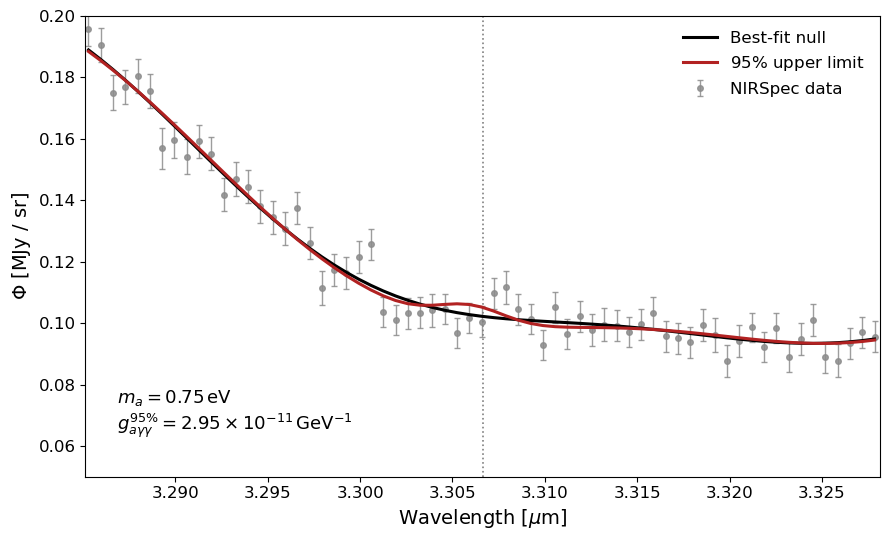

In [9]:
################################
###   Plot Example Analysis  ###
################################

fig, ax = plt.subplots(figsize=(9, 5.5))


################################
###   Data                   ###
################################

ax.errorbar(
    wavelength_fit, flux_fit,
    yerr=error_fit * null["error_scale"],
    fmt="o", ms=4, elinewidth=1, capsize=2,
    color="0.55", alpha=0.85,
    label="NIRSpec data", zorder=1,
)


################################
###   Models                 ###
################################

ax.plot(wavelength_fit, null["model"], color="black", lw=2.2,
        label="Best-fit null", zorder=3)

ax.plot(wavelength_fit, ul95["model"], color="firebrick", lw=2.2,
        label=r"$95\%$ upper limit", zorder=4)

ax.axvline(line_wavelength, color="0.5", lw=1.2, ls=":", zorder=2)


################################
###   Labels                 ###
################################

ax.set_xlabel(r"Wavelength [$\mu$m]", fontsize=14)
ax.set_ylabel(r"$\Phi$ [MJy / sr]", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=12)

annotation = (
    rf"$m_a = {MASS:.2f}\,\mathrm{{eV}}$" "\n"
    rf"$g^{{95\%}}_{{a\gamma\gamma}} = "
    rf"{ul95_coupling / 1e-11:.2f}\times10^{{-11}}\,\mathrm{{GeV}}^{{-1}}$"
)

ax.text(
    0.04, 0.08, annotation,
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=13,
)


################################
###   Legend / Limits        ###
################################

ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.set_xlim(fit_min, fit_max)
ax.set_ylim(0.05, 0.20)

fig.tight_layout()
plt.show()